# <h1 align="center">ADY201 — Final Project</h1>
## <h2 align="center">Python EDA — Exploratory Data Analysis</h2>

<div align="center">

**Dataset:** Instacart Market Basket Analysis (Kaggle)  
**Tools:** Python &nbsp;|&nbsp; Pandas &nbsp;|&nbsp; Matplotlib &nbsp;|&nbsp; Seaborn  
**Data source:** Microsoft SQL Server — pre-built VIEWs

</div>

---
## Table of Contents

1. [Library Setup](#b-setup)
2. [Database Connection](#b-connect)
3. [I. Basket Size Distribution](#section-I)
4. [II. Order Cycle Distribution](#section-II)
5. [III. Order Timing Heatmap](#section-III)
6. [IV. Feature Correlation Matrix](#section-IV)
7. [V. Reorder Rate by Product Group](#section-V)

---
## 1. Library Setup <a id="b-setup"></a>

**Prerequisites:**
- Dữ liệu đã được nạp vào SQL Server.
- `create_views_EDA_v2.sql` executed in SSMS — vw_basket_size, vw_order_cycle, vw_order_heatmap created.
- VIEW `feature_table` (Phần III) required for IV, V.

| Library | Purpose |
|---|---|
| `pandas` | Read data from SQL VIEWs |
| `numpy` | Numerical computation, regression |
| `matplotlib` | All static charts |
| `seaborn` | Heatmap, enhanced styling |
| `sqlalchemy` | SQL Server connection |

---

In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from sqlalchemy import create_engine, text
import os, warnings
warnings.filterwarnings("ignore")

os.makedirs("output/charts", exist_ok=True)

plt.rcParams.update({
    "font.size"        : 11,
    "axes.titlesize"   : 13,
    "axes.labelsize"   : 11,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "figure.dpi"       : 150,
})

print("Libraries imported successfully.")

Libraries imported successfully.


---
## 2. Database Connection <a id="b-connect"></a>

Each chart pulls data directly from the corresponding SQL VIEW.
Heavy aggregations (COUNT, GROUP BY, JOIN) are handled by SQL Server — Python only receives the final result set.

**Adjust `DATABASE`** if the name differs on your system.

---

In [2]:
SERVER   = "."
DATABASE = "Project_ADY201m"    
USERNAME = "ADY201m-Project"
PASSWORD = "123"

connection_url = (
    f"mssql+pyodbc://{USERNAME}:{PASSWORD}@{SERVER}/{DATABASE}"
    f"?driver=ODBC+Driver+17+for+SQL+Server&Encrypt=no"
)
engine = create_engine(connection_url, fast_executemany=True)

with engine.connect() as conn:
    db = conn.execute(text("SELECT DB_NAME()")).scalar()
    print(f"Connected to: [{db}]")

# Verify all 4 VIEWs exist
sql_chk = """
    SELECT name FROM sys.views
    WHERE  name IN ('vw_basket_size','vw_order_cycle','vw_order_heatmap',
                    'feature_table')
    ORDER  BY name
"""
with engine.connect() as conn:
    found = conn.execute(text(sql_chk)).fetchall()
    print(f"VIEWs found: {len(found)}/4")
    for v in found:
        print(f"  {v[0]}")

if len(found) < 4:
    print("WARNING: Missing VIEWs — run create_views_EDA_v2.sql in SSMS first.")

Connected to: [Project_ADY201m]
VIEWs found: 4/4
  feature_table
  vw_basket_size
  vw_order_cycle
  vw_order_heatmap


---
## I. Basket Size Distribution <a id="section-I"></a>

**Business question:** How many products does the average Instacart order contain?

| | |
|---|---|
| **VIEW** | `vw_basket_size` |
| **Data** | One row per order — `basket_size` = total products in that order |
| **Chart** | Histogram (distribution shape) + Boxplot (outlier detection) |

---

In [3]:
df_basket = pd.read_sql("SELECT basket_size FROM vw_basket_size", engine)
print(f"Rows loaded : {len(df_basket):,}")
print("\nDescriptive statistics:")
print(df_basket["basket_size"].describe().round(2))

Rows loaded : 3,214,874

Descriptive statistics:
count    3214874.00
mean          10.09
std            7.53
min            1.00
25%            5.00
50%            8.00
75%           14.00
max          145.00
Name: basket_size, dtype: float64


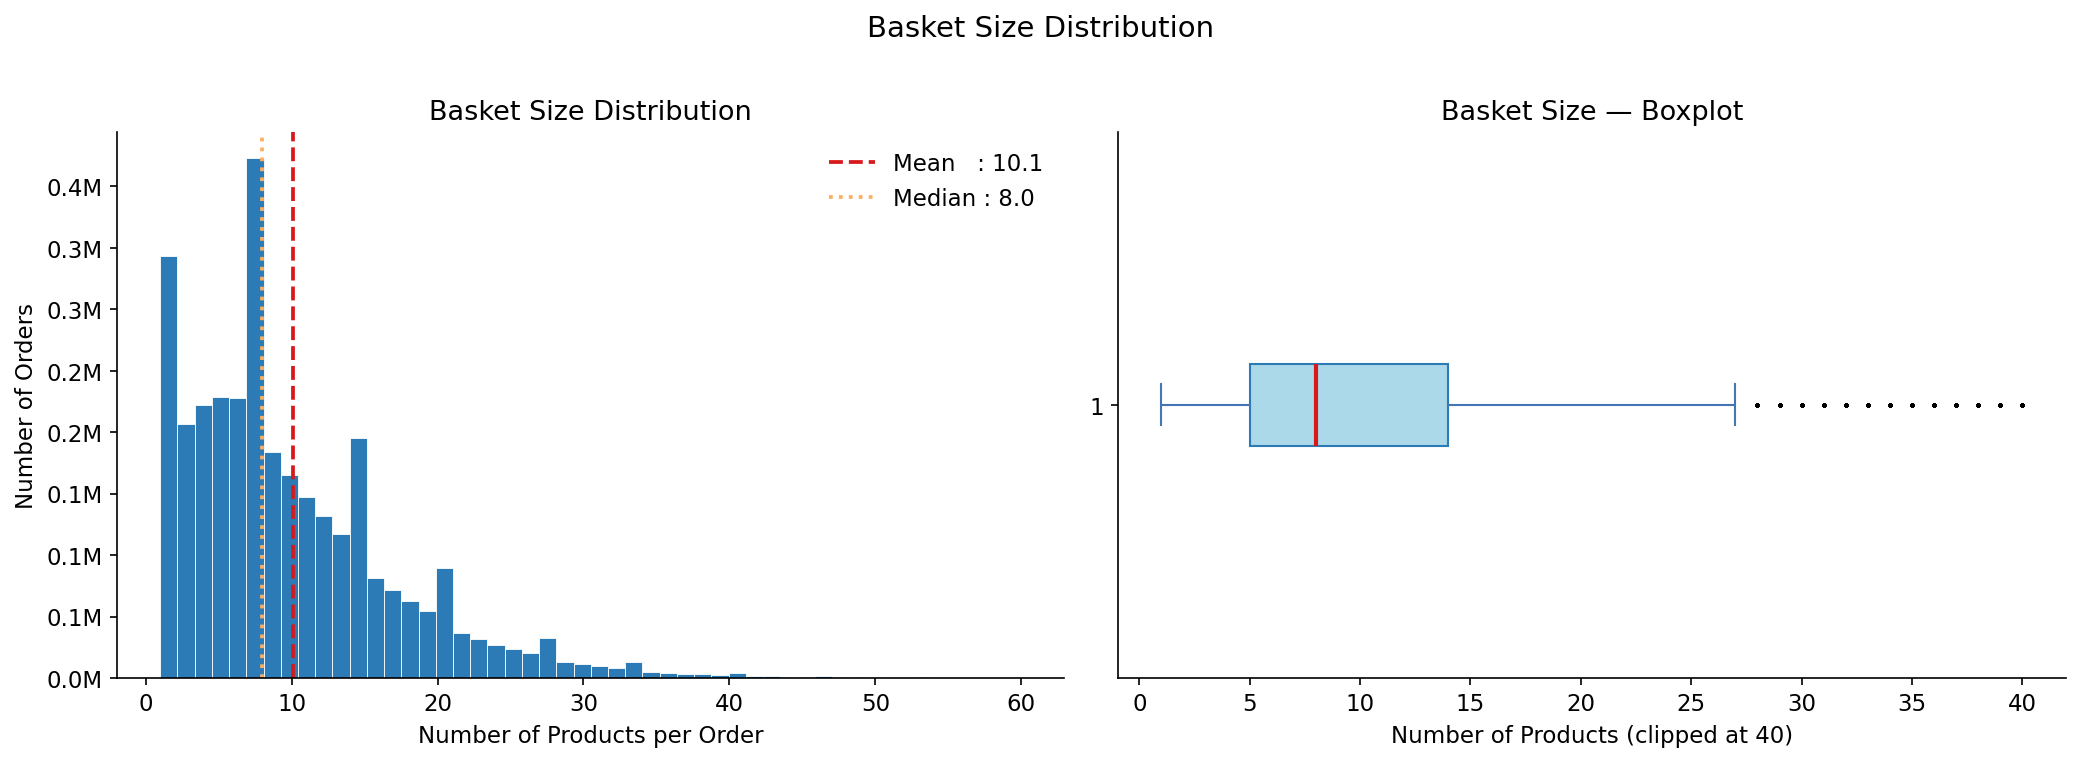

In [4]:
mean_val   = df_basket["basket_size"].mean()
median_val = df_basket["basket_size"].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Left: Histogram --
axes[0].hist(df_basket["basket_size"], bins=50, range=(1, 60),
             color="#2c7bb6", edgecolor="white", linewidth=0.4)
axes[0].axvline(mean_val,   color="#d7191c", linestyle="--", linewidth=1.8,
                label=f"Mean   : {mean_val:.1f}")
axes[0].axvline(median_val, color="#fdae61", linestyle=":",  linewidth=1.8,
                label=f"Median : {median_val:.1f}")
axes[0].set_xlabel("Number of Products per Order")
axes[0].set_ylabel("Number of Orders")
axes[0].set_title("Basket Size Distribution")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
axes[0].legend(frameon=False)

# -- Right: Boxplot --
axes[1].boxplot(df_basket["basket_size"].clip(upper=40), vert=False,
    patch_artist=True,
    boxprops    =dict(facecolor="#abd9e9", color="#2c7bb6"),
    medianprops =dict(color="#d7191c", linewidth=2),
    whiskerprops=dict(color="#4575b4"),
    capprops    =dict(color="#4575b4"),
    flierprops  =dict(marker=".", color="#aaa", markersize=2, alpha=0.3))
axes[1].set_xlabel("Number of Products (clipped at 40)")
axes[1].set_title("Basket Size — Boxplot")

plt.suptitle("Basket Size Distribution", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("output/charts/B1_basket_size.png", dpi=150, bbox_inches="tight")
plt.show()

---

**Phân tích biểu đồ:**

Phân phối kích thước giỏ hàng lệch phải (right-skewed): phần lớn đơn hàng có từ 3 đến 15 sản phẩm, tập trung nhiều nhất ở khoảng 5 sản phẩm. Giá trị trung bình (~10) lớn hơn trung vị, xác nhận sự lệch do một số đơn hàng quy mô rất lớn kéo phân phối sang phải. Boxplot cho thấy phần lớn đơn hàng nằm trong khoảng 5–15 sản phẩm, với nhiều điểm ngoại lệ phía trên cho thấy một nhóm nhỏ khách hàng có hành vi mua số lượng lớn trong một lần đặt. Đối với Instacart, thông tin này là cơ sở để xác định ngưỡng miễn phí giao hàng và thiết kế chiến lược upsell hướng đến tăng kích thước đơn trung bình.

---

---
## II. Order Cycle Distribution <a id="section-II"></a>

**Business question:** How many days pass between two consecutive orders? Are there anomalies?

| | |
|---|---|
| **VIEW** | `vw_order_cycle` |
| **Data** | Non-first orders only (`is_first_order = 0`) |
| **Chart** | Boxplot (top) + Histogram (bottom) — combined layout |

---

In [5]:
df_cycle = pd.read_sql(
    "SELECT days_since_prior_order FROM vw_order_cycle", engine)
print(f"Rows loaded: {len(df_cycle):,}")
print("\nDescriptive statistics (days):")
print(df_cycle["days_since_prior_order"].describe().round(2))

Rows loaded: 3,214,874

Descriptive statistics (days):
count    3214874.00
mean          11.11
std            9.21
min            0.00
25%            4.00
50%            7.00
75%           15.00
max           30.00
Name: days_since_prior_order, dtype: float64


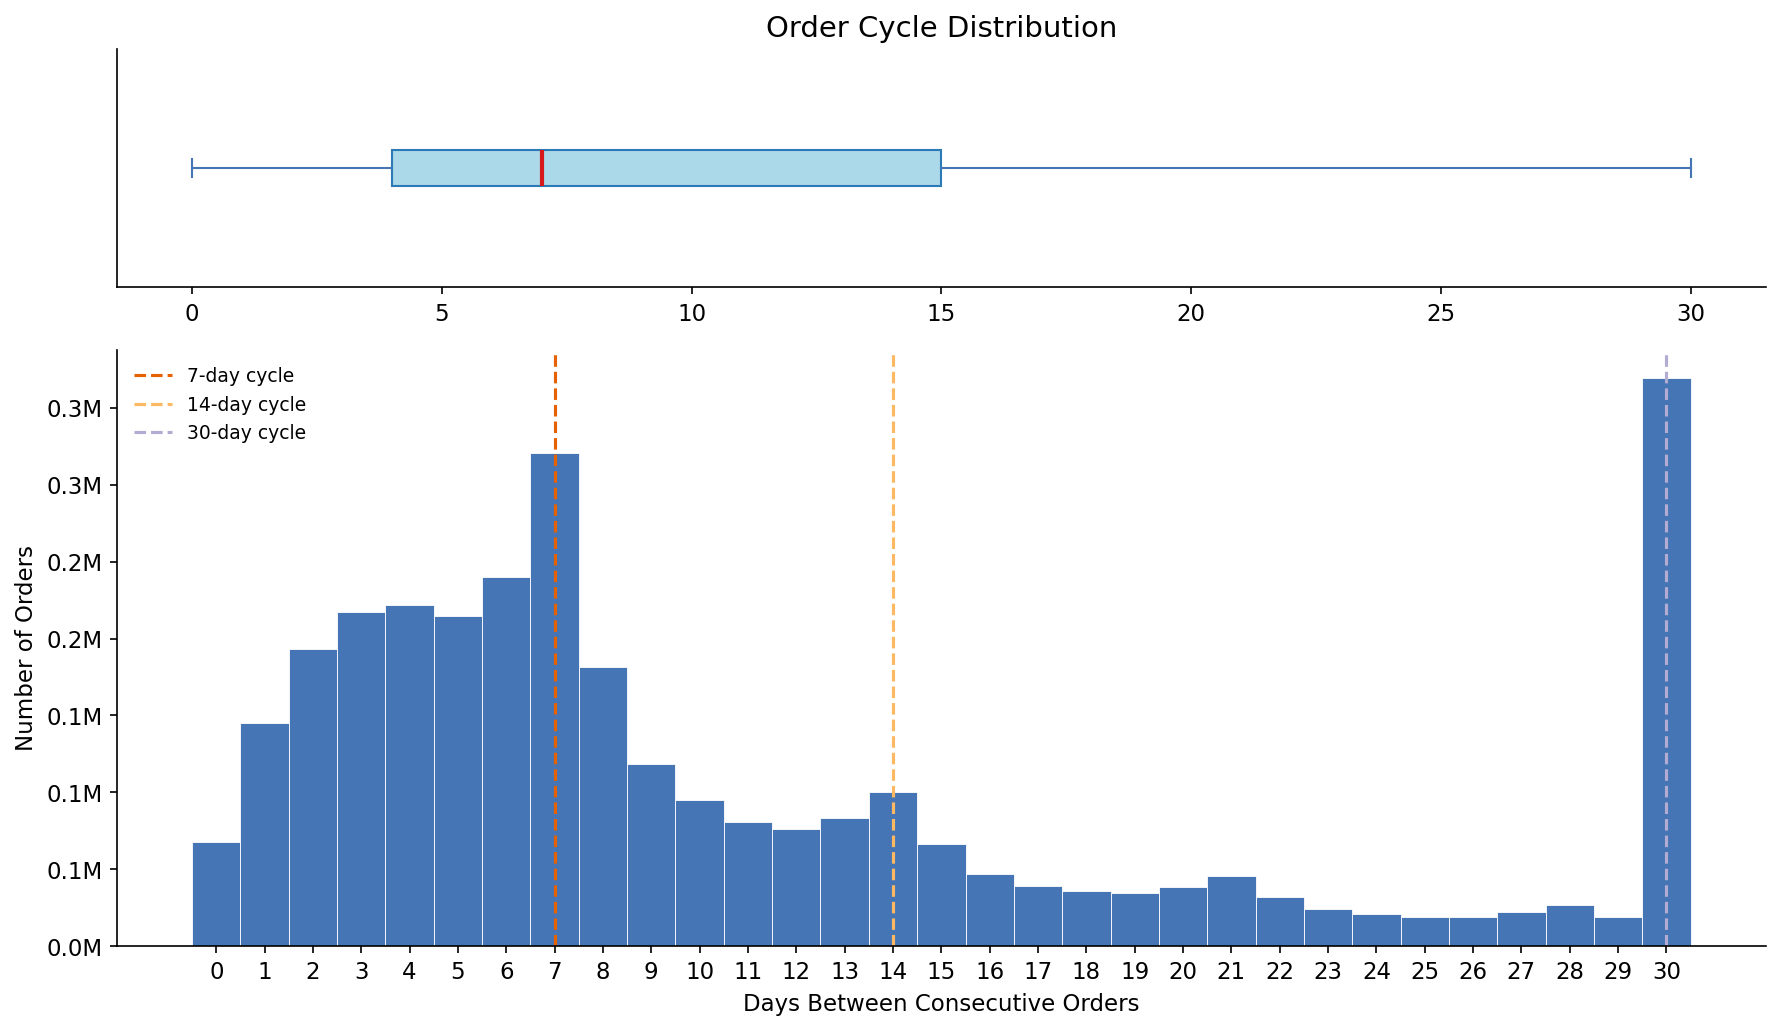

In [6]:
cycle = df_cycle["days_since_prior_order"]

fig, axes = plt.subplots(2, 1, figsize=(12, 7),
    gridspec_kw={"height_ratios": [1, 2.5]})

# -- Top: Boxplot --
axes[0].boxplot(cycle, vert=False, patch_artist=True,
    boxprops    =dict(facecolor="#abd9e9", color="#2c7bb6"),
    medianprops =dict(color="#d7191c", linewidth=2),
    whiskerprops=dict(color="#4575b4"),
    capprops    =dict(color="#4575b4"),
    flierprops  =dict(marker=".", color="#aaa", markersize=1, alpha=0.2))
axes[0].set_title("Order Cycle Distribution", fontsize=14)
axes[0].yaxis.set_visible(False)

# -- Bottom: Histogram --
axes[1].hist(cycle, bins=range(0, 32), color="#4575b4",
             edgecolor="white", linewidth=0.4, align="left")
axes[1].set_xlabel("Days Between Consecutive Orders")
axes[1].set_ylabel("Number of Orders")
axes[1].set_xticks(range(0, 31))
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

for day, lbl, col in [
    ( 7, "7-day cycle",   "#e66101"),
    (14, "14-day cycle",  "#fdb863"),
    (30, "30-day cycle",  "#b2abd2"),
]:
    axes[1].axvline(day, color=col, linestyle="--", linewidth=1.5, label=lbl)
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig("output/charts/B2_order_cycle.png", dpi=150, bbox_inches="tight")
plt.show()

---

**Phân tích biểu đồ:**

Histogram cho thấy ba đỉnh rõ ràng ở các mốc 7, 14 và 30 ngày — phản ánh các chu kỳ mua sắm tuần hoàn theo tuần và tháng. Mốc 30 ngày có đỉnh cao nhất, cho thấy đa số khách hàng mua sắm theo chu kỳ hàng tháng. Khoảng từ 0 đến 2 ngày cũng có lượng đơn đáng kể, thuộc về nhóm khách mua sắm thường xuyên hoặc bổ sung hàng ngay sau đó. Không có outlier nằm ngoài 30 ngày vì Instacart giới hạn trường này ở mức tối đa 30. Kết quả này là cơ sở để thiết kế chiến dịch nhắc nhở đặt hàng vào ngày thứ 6–7, thứ 13–14 và thứ 28–29 sau lần mua trước.

---

---
## III. Order Timing Heatmap <a id="section-III"></a>

**Business question:** When do customers place orders — which hours and days of the week are busiest?

| | |
|---|---|
| **VIEW** | `vw_order_heatmap` |
| **Data** | 168 rows (7 days × 24 hours) — pre-aggregated by SQL |
| **Chart** | Heatmap — best for comparing values across two categorical dimensions |

---

In [7]:
df_hm = pd.read_sql("SELECT * FROM vw_order_heatmap", engine)
n_days  = df_hm["order_dow"].nunique()
n_hours = df_hm["order_hour_of_day"].nunique()
print(f"Shape: {len(df_hm)} rows ({n_days} days x {n_hours} hours)")

hm_pivot = df_hm.pivot(
    index="order_dow", columns="order_hour_of_day", values="order_count")

# 0 = Sunday per Instacart convention
day_labels = ["Sun","Mon","Tue","Wed","Thu","Fri","Sat"]
hm_pivot.index = day_labels

total = int(df_hm["order_count"].sum())
print(f"Total orders in analysis: {total:,}")

Shape: 168 rows (7 days x 24 hours)
Total orders in analysis: 3,421,083


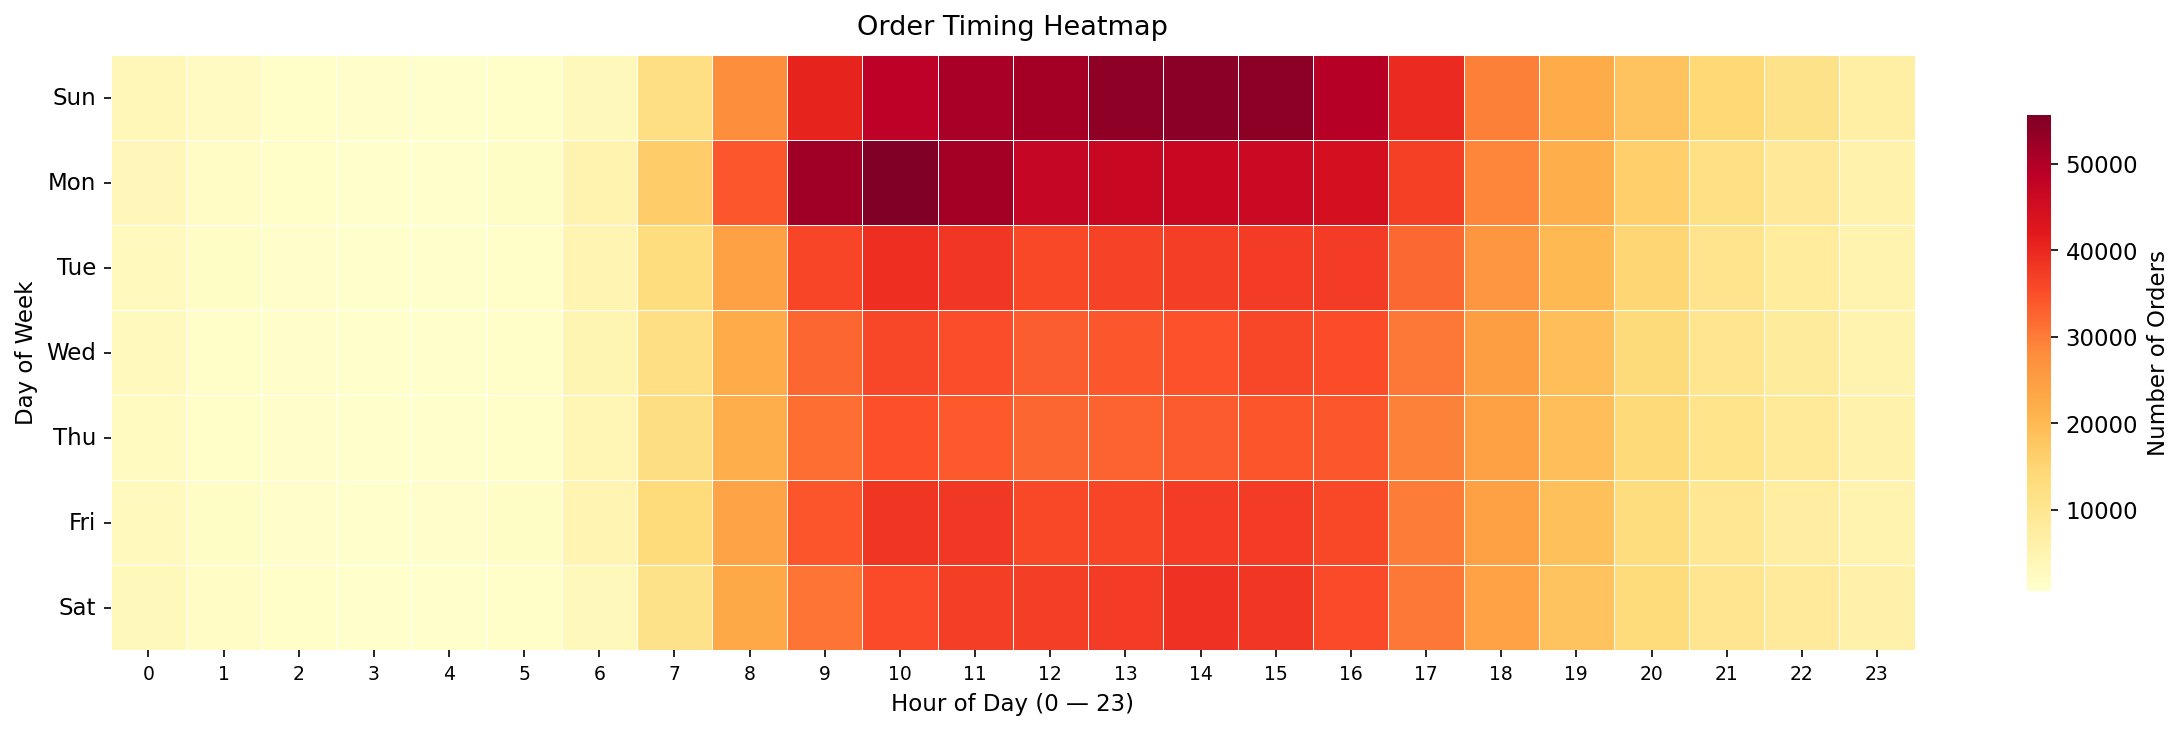

In [8]:
fig, ax = plt.subplots(figsize=(16, 5))

sns.heatmap(hm_pivot, cmap="YlOrRd", linewidths=0.3, linecolor="white",
            annot=False, ax=ax,
            cbar_kws={"label": "Number of Orders", "shrink": 0.8})

ax.set_title("Order Timing Heatmap", fontsize=13, pad=10)
ax.set_xlabel("Hour of Day (0 — 23)")
ax.set_ylabel("Day of Week")
ax.set_xticklabels(range(24), fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("output/charts/B3_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

---

**Phân tích biểu đồ:**

Bản đồ nhiệt cho thấy hai khung giờ cao điểm chính là 10–15 giờ, trong đó 10–11 giờ sáng là thời điểm có nhiều đơn nhất trong cả tuần. Chủ nhật và Thứ Hai là hai ngày bận rộn nhất, với màu đỏ đậm kéo dài từ sáng đến chiều. Ngược lại, khung 0–5 giờ sáng rất ít đơn trên tất cả các ngày. Thông tin này giúp Instacart phân bổ nhân lực giao hàng đúng ca, lên lịch các chiến dịch khuyến mãi vào đầu tuần và buổi sáng, đồng thời tối ưu hóa khung giờ giao hàng dự kiến cho từng vùng.

---

---
## IV. Ma trận tương quan đặc trưng và biến mục tiêu <a id="section-IV"></a>

**Business question:** 6 đặc trưng dự kiến đưa vào mô hình XGBoost (đã được lựa chọn dựa trên giả thuyết nghiệp vụ — xem Phần III báo cáo) có thực sự tương quan với khả năng đặt lại sản phẩm (`reordered`) không? Có cặp đặc trưng nào tương quan quá cao với nhau (đa cộng tuyến) cần lưu ý không?

| | |
|---|---|
| **Nguồn dữ liệu** | VIEW `feature_table` (đọc toàn bộ qua `pd.read_sql()`, không lấy mẫu) |
| **Vai trò của biểu đồ** | **Kiểm chứng** giả thuyết nghiệp vụ đã nêu ở Phần III — không phải khám phá đặc trưng mới từ đầu |
| **Chart** | Heatmap ma trận tương quan (Pearson) |

> **Lưu ý:** Biểu đồ này không quyết định việc chọn đặc trưng — 6 đặc trưng đã được chốt từ Phần III dựa trên lý do nghiệp vụ. Biểu đồ chỉ xác nhận (hoặc đặt câu hỏi) cho các giả thuyết đó bằng số liệu thật, trước khi đưa vào huấn luyện mô hình ở phần Python ML.

---

In [10]:
df_feat = pd.read_sql("SELECT * FROM feature_table", engine)

print(f"\nSo dong: {len(df_feat):,}")
print(f"So cot : {df_feat.shape[1]}")
print("\nTy le nhan reordered:")
print(df_feat["reordered"].value_counts(normalize=True).round(3))
print("\n5 dong dau:")
display(df_feat.head())


So dong: 1,384,617
So cot : 10

Ty le nhan reordered:
reordered
1    0.599
0    0.401
Name: proportion, dtype: float64

5 dong dau:


,order_id,user_id,product_id,reordered,user_total_orders,user_avg_days_between_orders,user_reorder_ratio,product_reorder_rate,avg_add_to_cart_position,user_product_times_bought
0,1183739,184567,18234,1,16,14.250000,0.6250,0.5795,8.173351,7
1,2341149,138086,21497,1,38,9.263158,0.6102,0.6742,7.511135,32
2,1842240,109737,47766,1,5,23.400000,0.2958,0.7581,6.444617,1
3,1541175,14592,46979,1,6,20.166667,0.1818,0.6181,8.804349,1
4,3121302,57897,1633,1,44,8.250000,0.7599,0.4815,9.532922,2


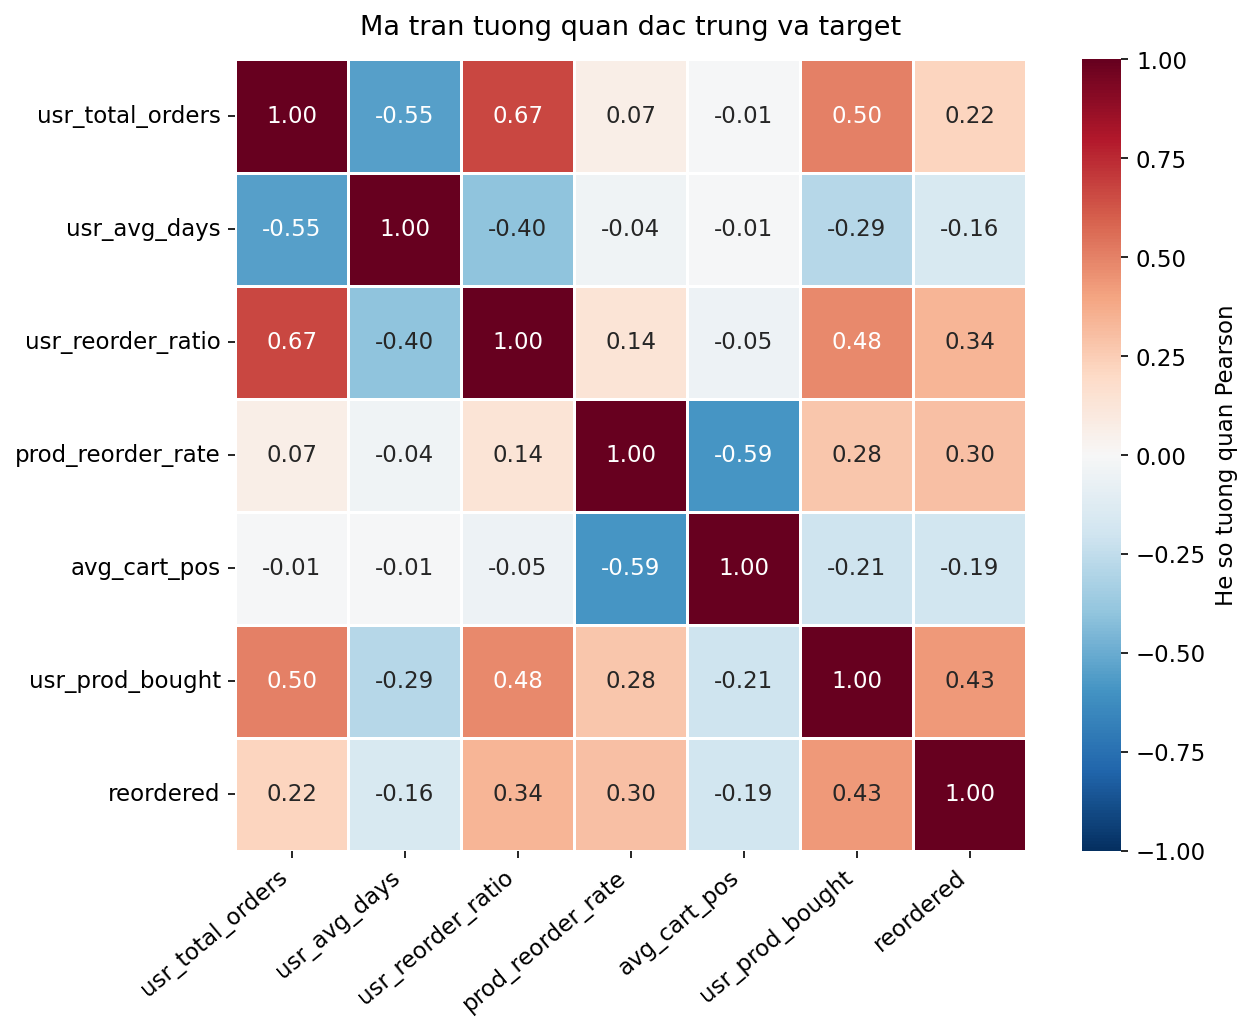


Tuong quan voi reordered (sap xep theo do manh):
user_product_times_bought       0.434
user_reorder_ratio              0.342
product_reorder_rate            0.304
user_total_orders               0.224
avg_add_to_cart_position       -0.188
user_avg_days_between_orders   -0.163
Name: reordered, dtype: float64


In [11]:
FEATURES = [
    'user_total_orders',
    'user_avg_days_between_orders',
    'user_reorder_ratio',
    'product_reorder_rate',
    'avg_add_to_cart_position',
    'user_product_times_bought'
]
TARGET = 'reordered'

FEAT_LABELS = {
    'user_total_orders':            'usr_total_orders',
    'user_avg_days_between_orders': 'usr_avg_days',
    'user_reorder_ratio':           'usr_reorder_ratio',
    'product_reorder_rate':         'prod_reorder_rate',
    'avg_add_to_cart_position':     'avg_cart_pos',
    'user_product_times_bought':    'usr_prod_bought',
    'reordered':                    'reordered'
}

corr_matrix = df_feat[FEATURES + [TARGET]].corr()
corr_display = corr_matrix.rename(index=FEAT_LABELS, columns=FEAT_LABELS)

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(corr_display, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor="white",
            square=True, ax=ax,
            cbar_kws={"label": "He so tuong quan Pearson"})

ax.set_title("Ma tran tuong quan dac trung va target", fontsize=13, pad=12)
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("output/charts/B4_feature_target_corr.png", dpi=150, bbox_inches="tight")
plt.show()

# In rieng tuong quan voi target, sap xep theo do manh (gia tri tuyet doi)
corr_target = corr_matrix[TARGET].drop(TARGET)
corr_target_sorted = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index)
print("\nTuong quan voi reordered (sap xep theo do manh):")
print(corr_target_sorted.round(3))

---

**Phân tích biểu đồ:**

Trong số 6 đặc trưng dự kiến, `user_product_times_bought` có hệ số tương quan mạnh nhất với `reordered` (r = 0.43), xác nhận đúng giả thuyết nghiệp vụ đã nêu ở Phần III — số lần đã mua trước đó là tín hiệu dự đoán quan trọng. Tuy nhiên cần lưu ý một điểm về bản chất dữ liệu: theo định nghĩa của Instacart, `reordered = 1` nghĩa là người dùng đã từng mua đúng sản phẩm này trước đó — do đó `user_product_times_bought` và `reordered` có quan hệ gần như tất định (nếu đã mua ≥ 1 lần trước, sản phẩm gần như chắc chắn được tính là "đặt lại"), không hoàn toàn là một tín hiệu hành vi tinh vi mà mô hình "học" ra. Hai đặc trưng tiếp theo có tương quan đáng kể và mang tính hành vi thực sự là `user_reorder_ratio` (r = 0.34) và `product_reorder_rate` (r = 0.30) — phản ánh đúng thói quen đặt lại của từng khách hàng và đặc tính riêng của từng sản phẩm. Hai đặc trưng yếu nhất là `avg_add_to_cart_position` (r = -0.19) và `user_avg_days_between_orders` (r = -0.16) — vẫn đáng giữ lại vì XGBoost xử lý tốt các đặc trưng có tín hiệu yếu mà không gây hại. Về đa cộng tuyến: `user_total_orders` tương quan khá cao với `user_reorder_ratio` (r = 0.67) và với `user_avg_days_between_orders` (r = -0.55); `product_reorder_rate` cũng tương quan ngược đáng kể với `avg_add_to_cart_position` (r = -0.59) — đây không phải vấn đề nghiêm trọng với mô hình tree-based như XGBoost, nhưng cần ghi nhận khi diễn giải feature importance ở phần Python ML.

---

---
## V. Tỷ lệ đặt lại theo nhóm sản phẩm <a id="section-V"></a>

**Business question:** Sản phẩm có đặc tính "dễ được đặt lại" trên toàn platform (product_reorder_rate cao — ví dụ sữa, giấy vệ sinh) có thực sự dẫn đến tỷ lệ đặt lại cao hơn ở từng lượt mua cụ thể không? Mức tăng cụ thể là bao nhiêu giữa nhóm sản phẩm thấp nhất và cao nhất?

| | |
|---|---|
| **Nguồn dữ liệu** | Dùng lại `df_feat` đã đọc ở mục IV — không đọc lại từ SQL |
| **Vai trò của biểu đồ** | Kiểm chứng giả thuyết: đặc tính sản phẩm (product_reorder_rate) có chuyển hóa thành hành vi đặt lại thực tế ở từng lượt mua không |
| **Chart** | Bar chart — % đặt lại theo 5 nhóm product_reorder_rate (ngũ phân — quintile) |

---

In [12]:
NHAN_NHOM = ["Rat thap", "Thap", "Trung binh", "Cao", "Rat cao"]

df_feat["nhom_product_reorder"] = pd.qcut(
    df_feat["product_reorder_rate"],
    q=5,
    labels=NHAN_NHOM
)

ty_le_dat_lai_2 = (
    df_feat.groupby("nhom_product_reorder")["reordered"]
    .mean()
    .reindex(NHAN_NHOM) * 100
)
so_luong_2 = df_feat.groupby("nhom_product_reorder").size().reindex(NHAN_NHOM)

khoang_gia_tri = (
    df_feat.groupby("nhom_product_reorder")["product_reorder_rate"]
    .agg(["min", "max"])
    .reindex(NHAN_NHOM)
)

print("Khoang product_reorder_rate moi nhom:")
print(khoang_gia_tri.round(3))
print("\nTy le dat lai thuc te (%) moi nhom:")
print(ty_le_dat_lai_2.round(2))
print("\nSo luong ban ghi moi nhom:")
print(so_luong_2)

Khoang product_reorder_rate moi nhom:
                        min    max
nhom_product_reorder              
Rat thap              0.000  0.465
Thap                  0.465  0.564
Trung binh            0.564  0.634
Cao                   0.634  0.702
Rat cao               0.702  0.941

Ty le dat lai thuc te (%) moi nhom:
nhom_product_reorder
Rat thap      37.09
Thap          53.86
Trung binh    61.60
Cao           68.30
Rat cao       78.49
Name: reordered, dtype: float64

So luong ban ghi moi nhom:
nhom_product_reorder
Rat thap      277311
Thap          276600
Trung binh    277017
Cao           277199
Rat cao       276490
dtype: int64


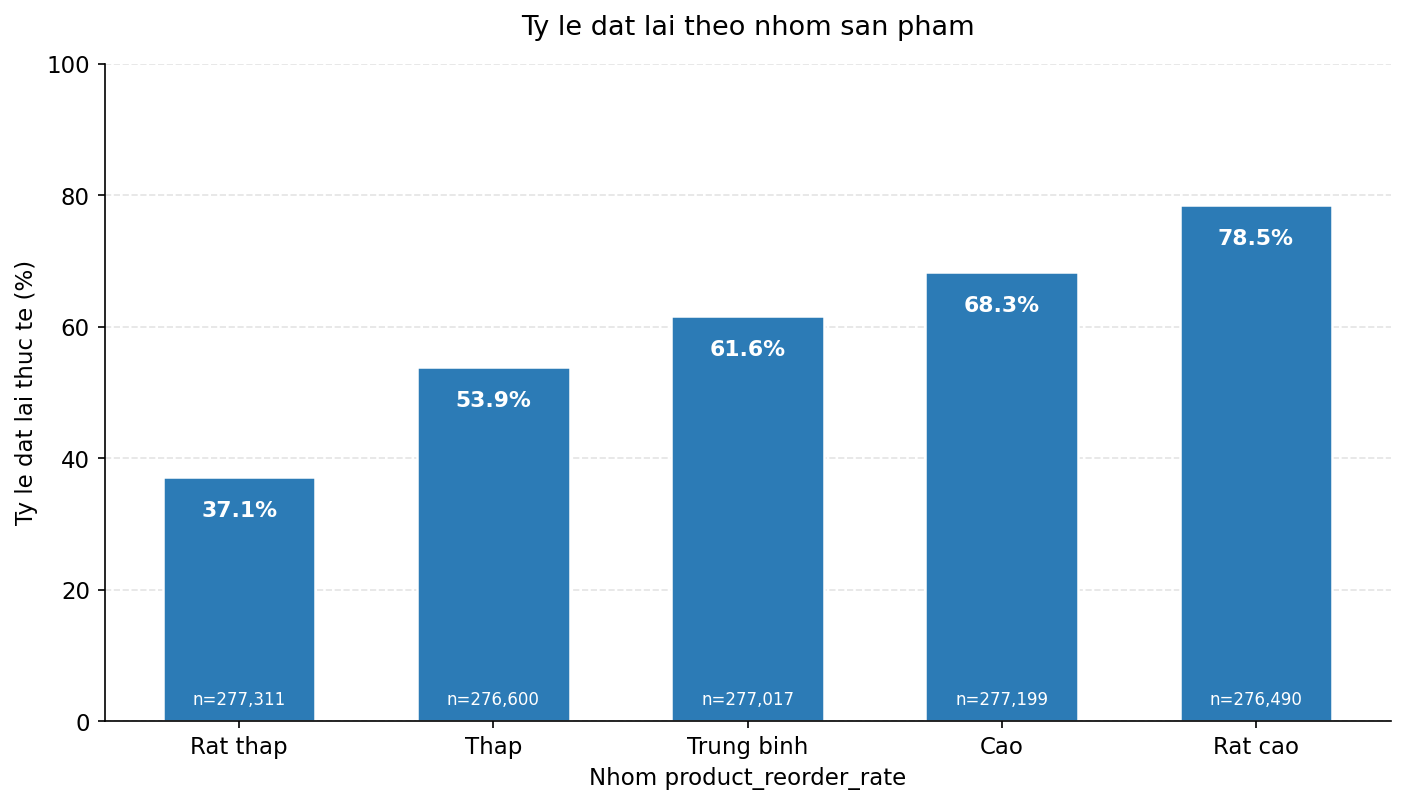

In [13]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))

bars = ax.bar(NHAN_NHOM, ty_le_dat_lai_2.values,
              color="#2c7bb6", edgecolor="white", linewidth=1.2, width=0.6)

for bar, val, n in zip(bars, ty_le_dat_lai_2.values, so_luong_2.values):
    ax.text(bar.get_x() + bar.get_width()/2, val - 6,
            f"{val:.1f}%", ha="center", fontsize=10.5,
            fontweight="bold", color="white")
    ax.text(bar.get_x() + bar.get_width()/2, 2.5,
            f"n={n:,}", ha="center", fontsize=8, color="white")

ax.set_xlabel("Nhom product_reorder_rate")
ax.set_ylabel("Ty le dat lai thuc te (%)")
ax.set_title("Ty le dat lai theo nhom san pham", fontsize=13, pad=14)
ax.set_ylim(0, 100)
ax.grid(True, axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("output/charts/B5_reorder_by_product_rate.png", dpi=150, bbox_inches="tight")
plt.show()

---

**Phân tích biểu đồ:**

Tỷ lệ đặt lại tăng đều và rõ rệt theo từng nhóm product_reorder_rate: từ 37.1% ở nhóm "Rất thấp" lên đến 78.5% ở nhóm "Rất cao" — chênh lệch hơn 41 điểm phần trăm giữa hai đầu. Mức tăng diễn ra đồng đều qua các nhóm liên tiếp (37.1% → 53.9% → 61.6% → 68.3% → 78.5%), không có bước nhảy bất thường ở bất kỳ ngưỡng nào, cho thấy `product_reorder_rate` có quan hệ gần như tuyến tính với hành vi đặt lại thực tế, không chỉ là một con số tổng hợp tách biệt khỏi từng lượt mua cụ thể. Kết quả này xác nhận đúng giả thuyết nghiệp vụ đã nêu ở Phần III: đặc tính lặp lại của sản phẩm (ví dụ sữa, giấy vệ sinh — loại hàng tiêu hao định kỳ) thực sự chuyển hóa thành hành vi đặt lại ở cấp độ từng đơn hàng, khác với `user_product_times_bought` ở biểu đồ trước — vốn mang tính tất định theo định nghĩa dữ liệu. Đây là cơ sở để Instacart ưu tiên hiển thị gợi ý "mua lại nhanh" ngay tại các sản phẩm thuộc nhóm "Cao" và "Rất cao", nơi xác suất khách hàng mua lại đã vượt 68%.

---
